# Visualización Individual por Lotes (Múltiples Muestras MIDI)

**Finalidad del Notebook:**  
El objetivo principal de este documento es automatizar la extracción y renderizado visual de múltiples piezas musicales, representándolas como series de tiempo independientes. A diferencia del análisis continuo (donde se concatenan las secuencias), aquí generaremos **un gráfico aislado para cada archivo MIDI**, reiniciando el contador de tiempo al inicio de cada canción. Esto resulta ideal para inspeccionar visualmente la distribución de densidad de notas (*pitch* vs tiempo) y la estructura rítmica individual de diversas muestras en un solo proceso por lotes.

### Importación de Librerías
* `os` y `glob`: Esenciales para acceder al sistema de archivos y capturar todas las rutas de las canciones.
* `mido`: Herramienta principal para parsear la estructura de los archivos `.midi` y extraer los eventos secuenciales.
* `pandas` y `numpy`: Para manipulaciones de estructuras de datos bidimensionales y cálculos numéricos.
* `matplotlib.pyplot` y `seaborn`: Motores gráficos utilizados para estructurar y dibujar los planos cartesianos.


In [1]:
import os
from glob import glob
import random
import mido
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Exploración del Directorio del Dataset
Se define la variable `ruta_base` apuntando al dataset local. A través de la función `glob` con búsqueda recursiva, identificamos y recolectamos en la lista `archivos` todas las direcciones absolutas de las pistas en formato MIDI. Esto nos proporciona el insumo de rutas necesarias para alimentar el motor de visualización.

In [2]:
ruta_base = '../maestro-v3.0.0'
archivos = glob(os.path.join(ruta_base, '**/*.midi*'), recursive=True)

### Función de Extracción y Gráficos Independientes
Se define la rutina `visualizar_por_archivo`, diseñada para iterar de manera controlada sobre el conjunto de datos:

1. **Control de Lotes:** Utiliza la técnica de *slicing* `[:limite]` en el bucle principal para garantizar que la memoria y el renderizado gráfico no se sobrecarguen, deteniendo el análisis al alcanzar el número de iteraciones deseado.
2. **Reinicio Dinámico:** A diferencia del modelado continuo, el arreglo de `tiempos`, `notas` y el contador `tiempo_actual = 0` **se declaran dentro del bucle**. Esto asegura un restablecimiento total de las variables cada vez que inicia una nueva canción.
3. **Generación de Lienzos Aislados:** La declaración de `plt.figure(figsize=(20, 6))` y la instrucción de cierre `plt.show()` habitan *dentro* del bucle. Este diseño algorítmico es el responsable de "imprimir" y cerrar una gráfica completa antes de pasar a procesar el siguiente archivo MIDI, extrayendo incluso el nombre del archivo para etiquetar dinámicamente cada título.


In [5]:
def visualizar_por_archivo(lista_archivos, limite):

    for i, ruta in enumerate(lista_archivos[:limite]):
        mid = mido.MidiFile(ruta)
        tiempos = []
        notas = []
        tiempo_actual = 0
        
        for msg in mid:
            tiempo_actual += msg.time
            if msg.type == 'note_on' and msg.velocity > 0:
                tiempos.append(tiempo_actual)
                notas.append(msg.note)
        
        plt.figure(figsize=(20, 6))
        plt.plot(tiempos, notas, color='tab:blue', linewidth=0.8, alpha=0.7)
        plt.scatter(tiempos, notas, s=1, color='black', alpha=0.5)
        
        nombre_archivo = os.path.basename(ruta)
        plt.title(f"Serie de Tiempo #{i+1}: {nombre_archivo}")
        plt.xlabel("Tiempo")
        plt.ylabel("Pitch (Nota)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### Ejecución del Lote de Visualizaciones
Llamamos a nuestra función de renderizado inyectándole nuestra lista de archivos y un parámetro de corte numérico (límite). Esto desencadenará el proceso de iteración que nos devolverá el conjunto de visualizaciones analíticas individuales.

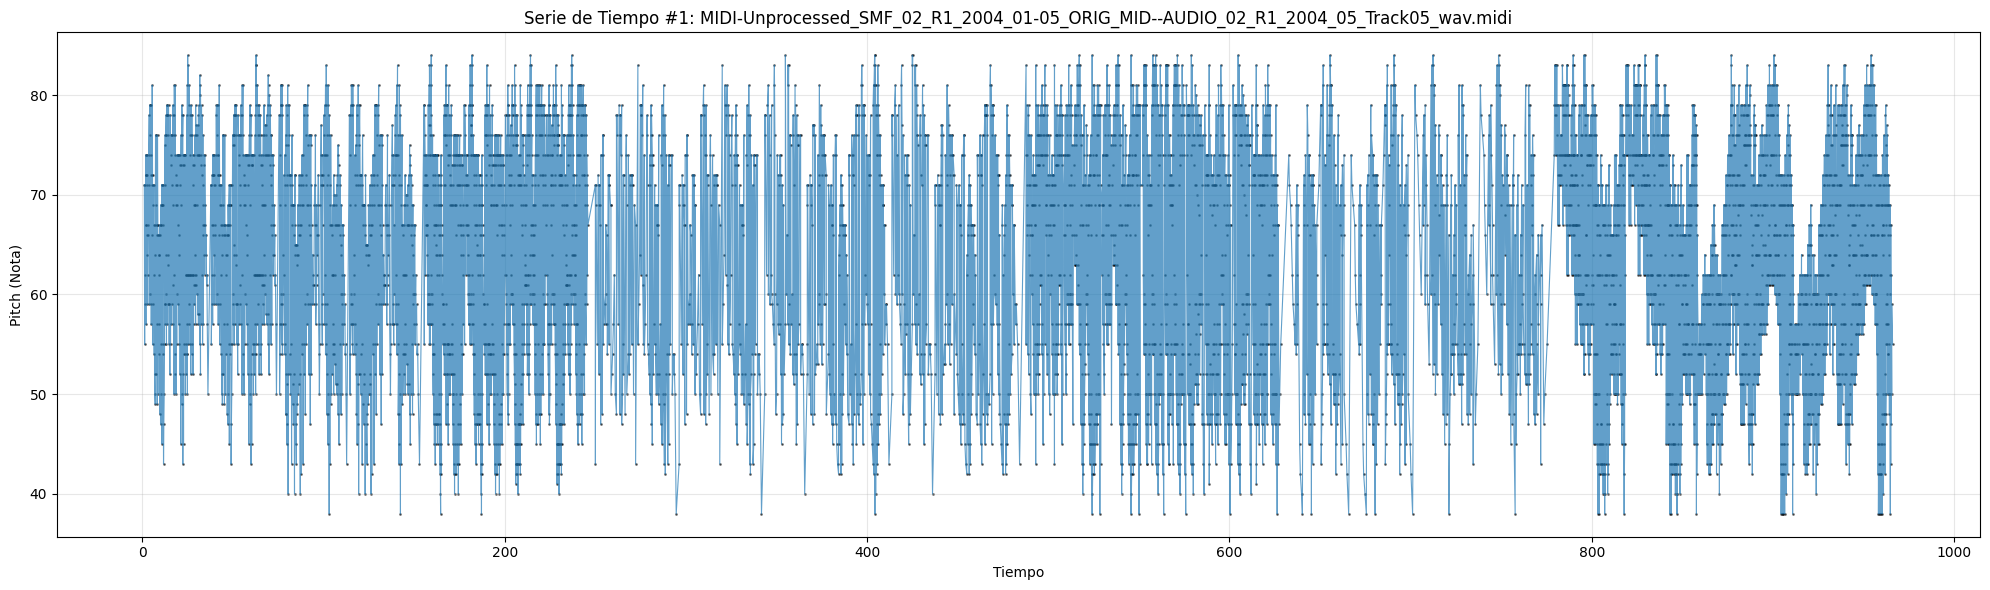

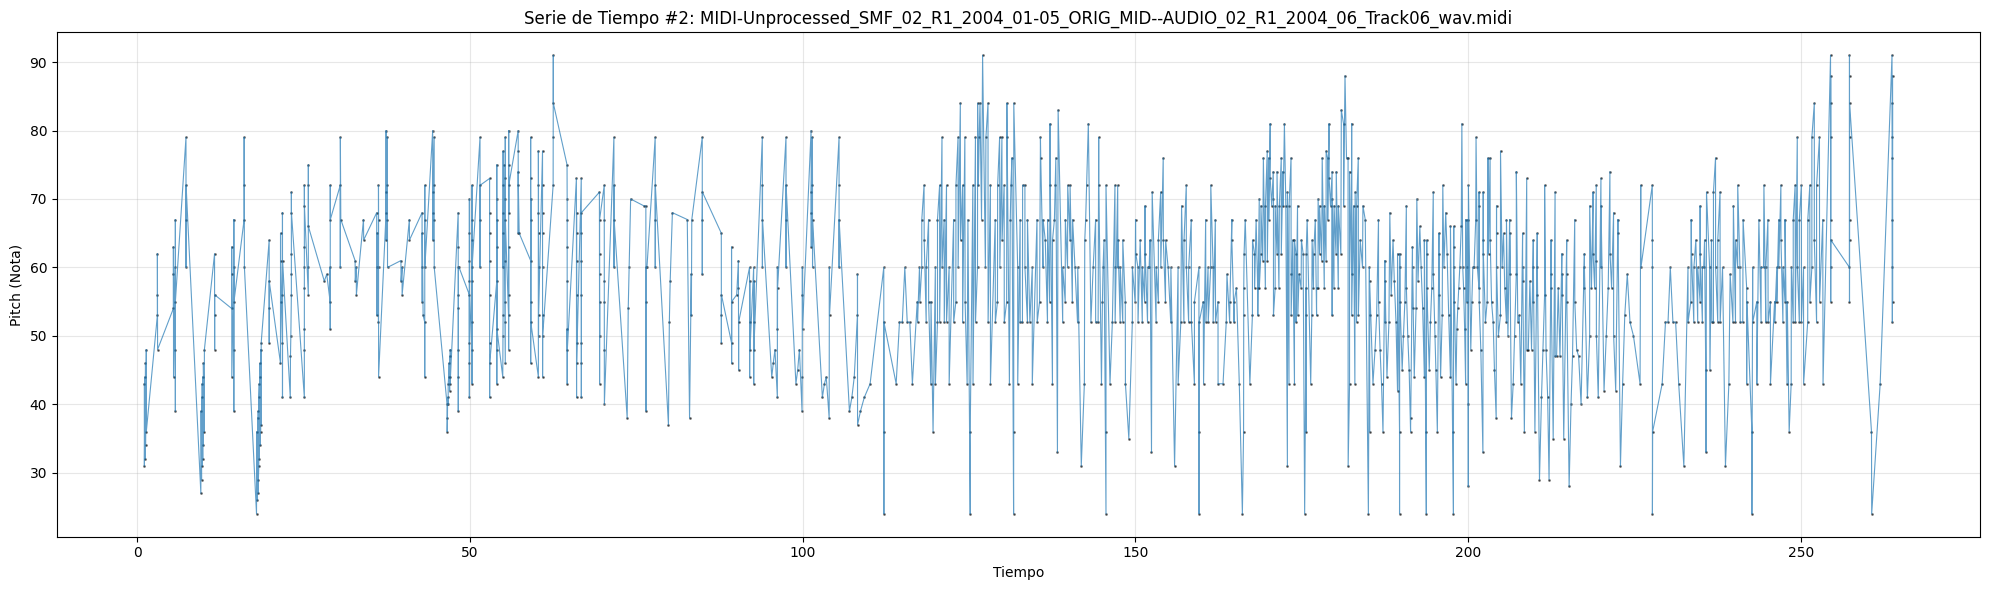

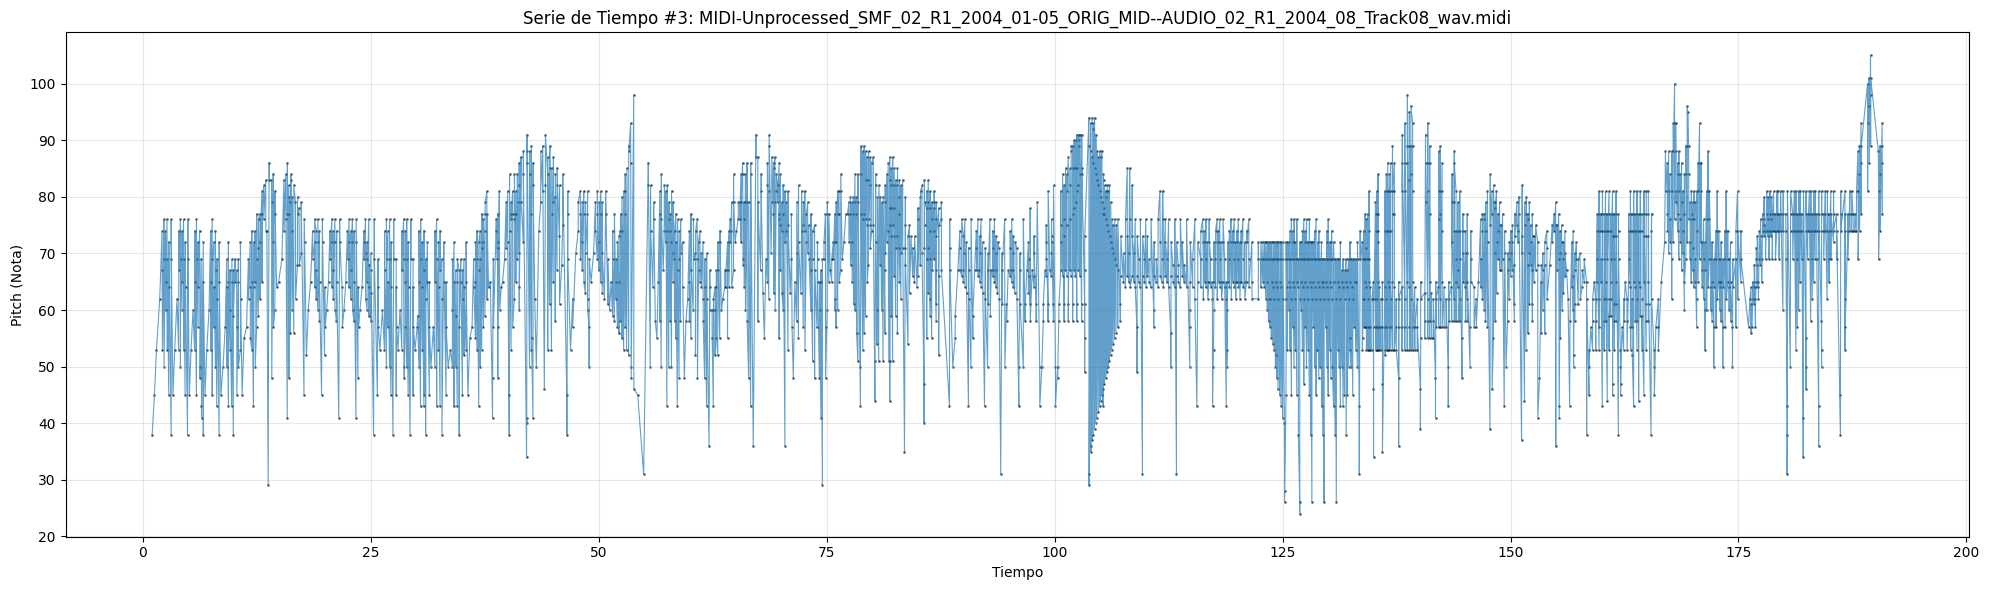

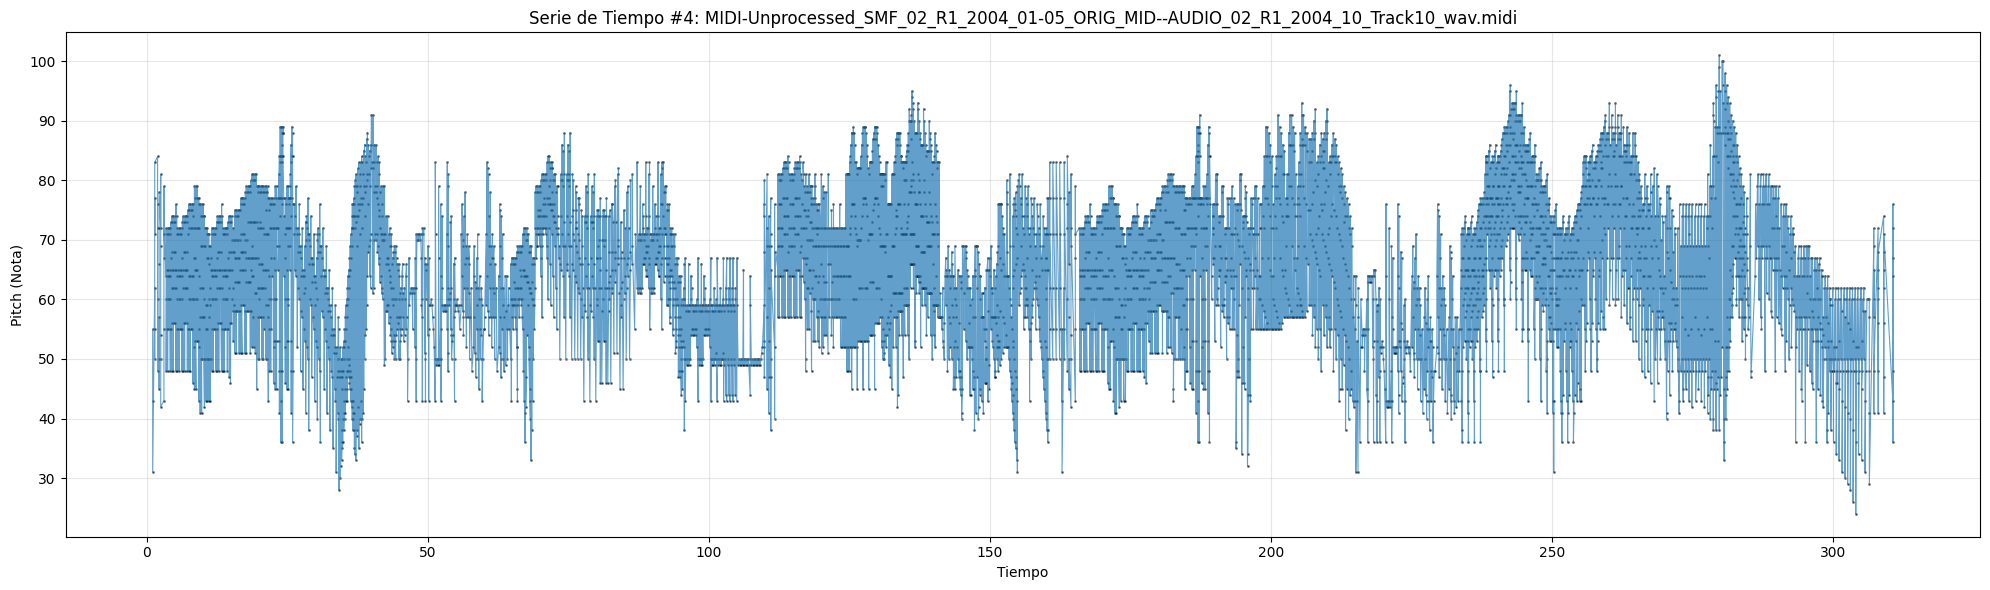

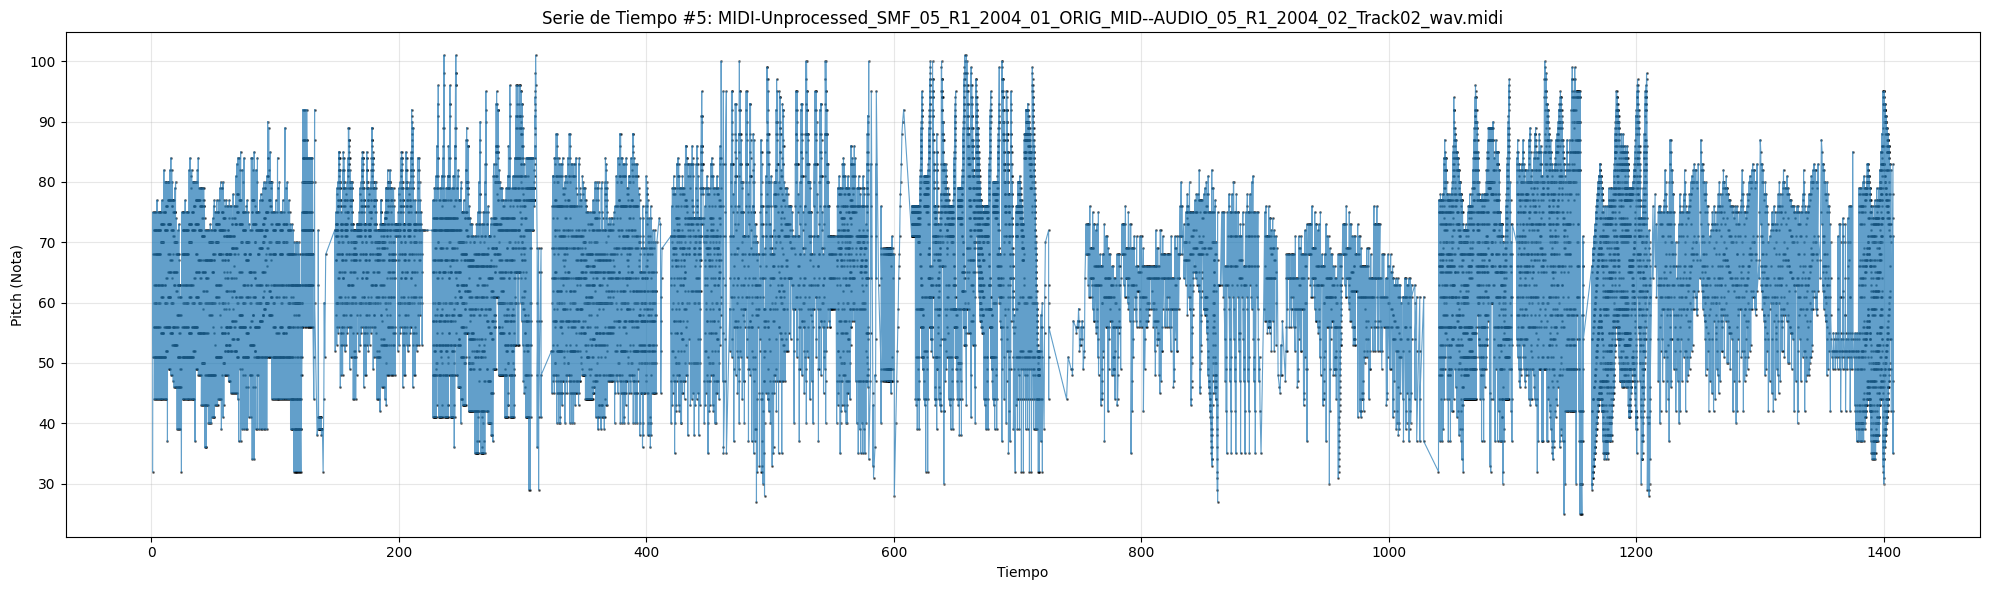

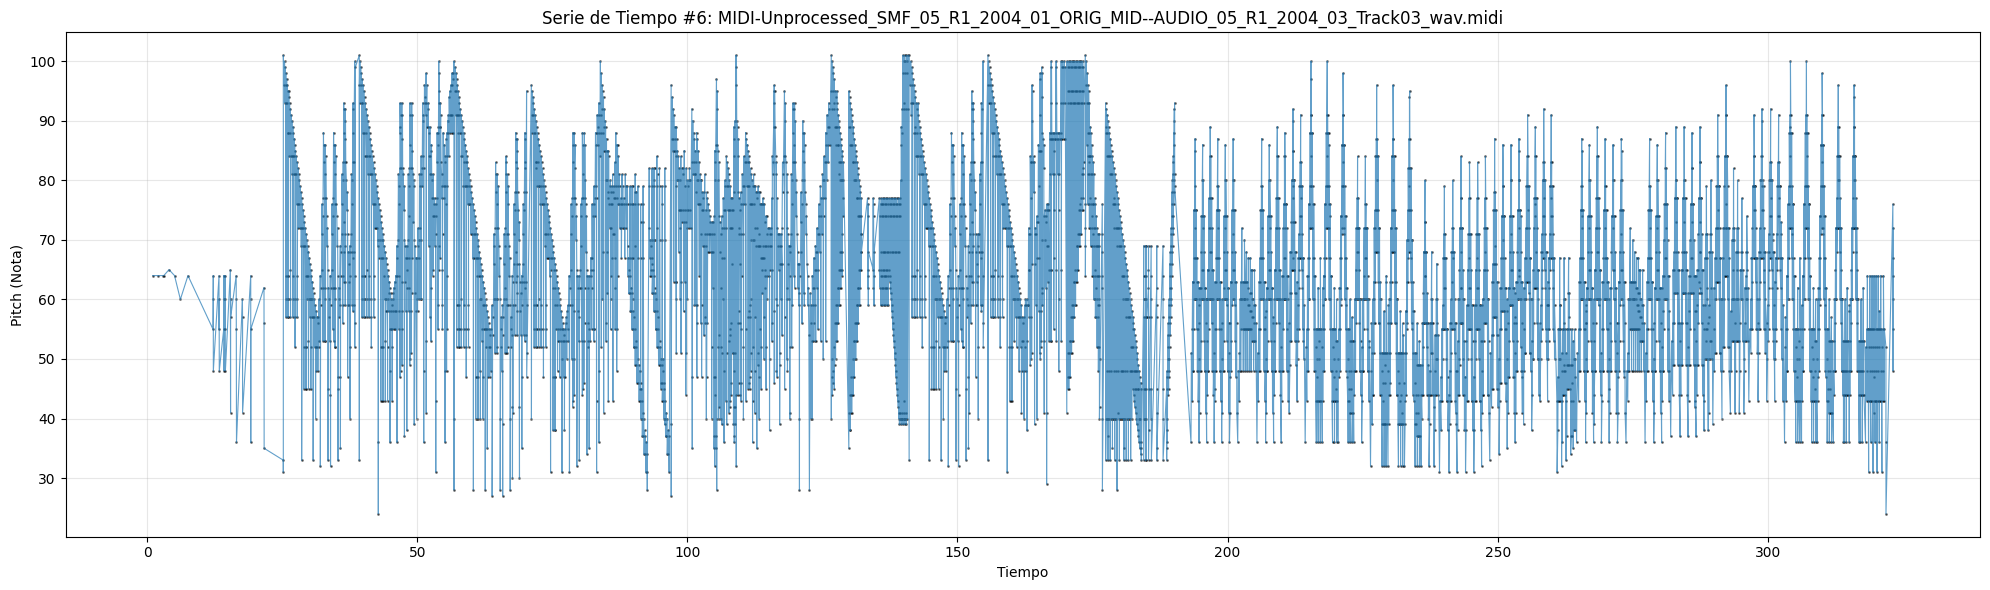

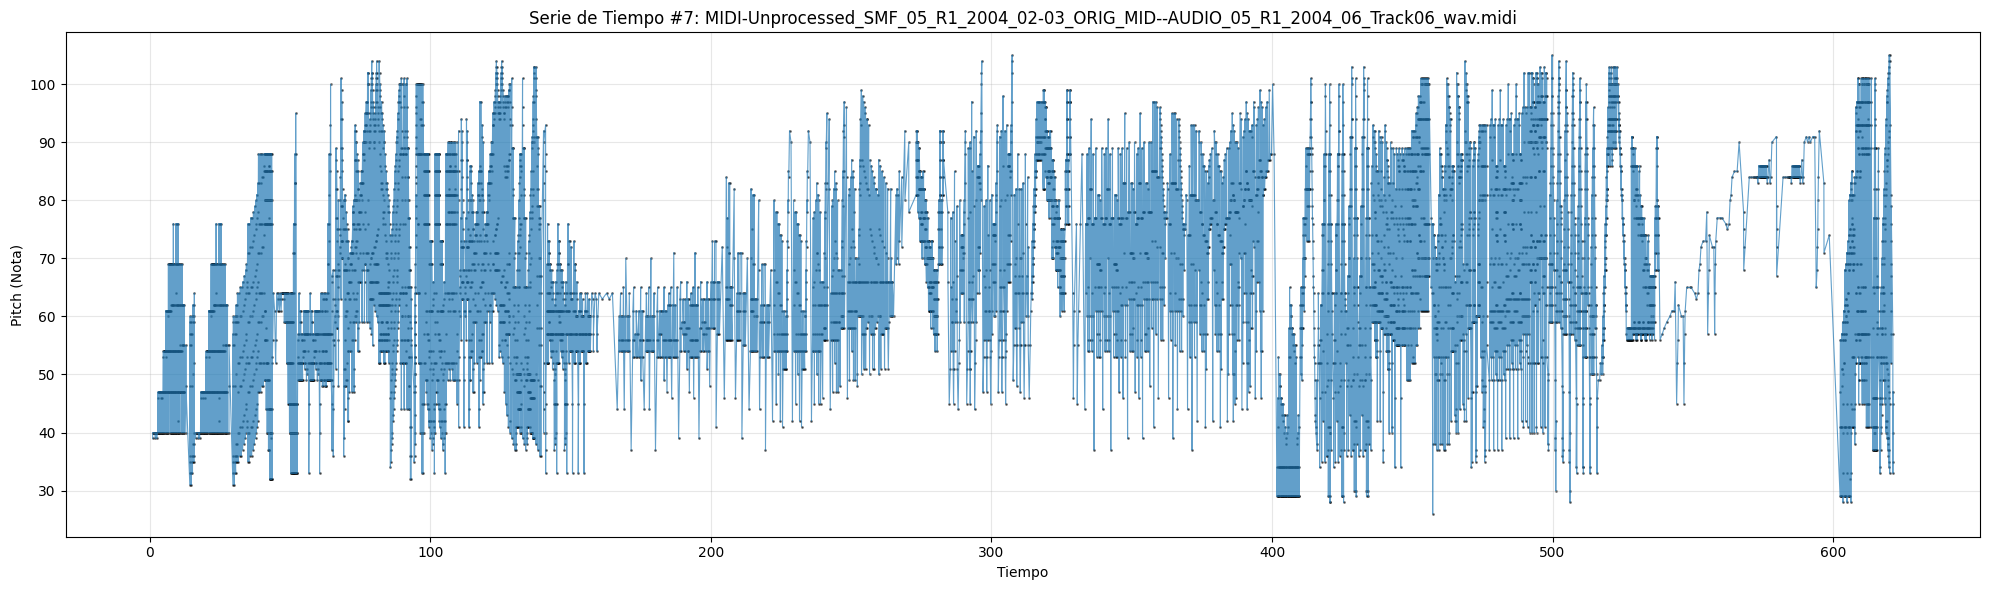

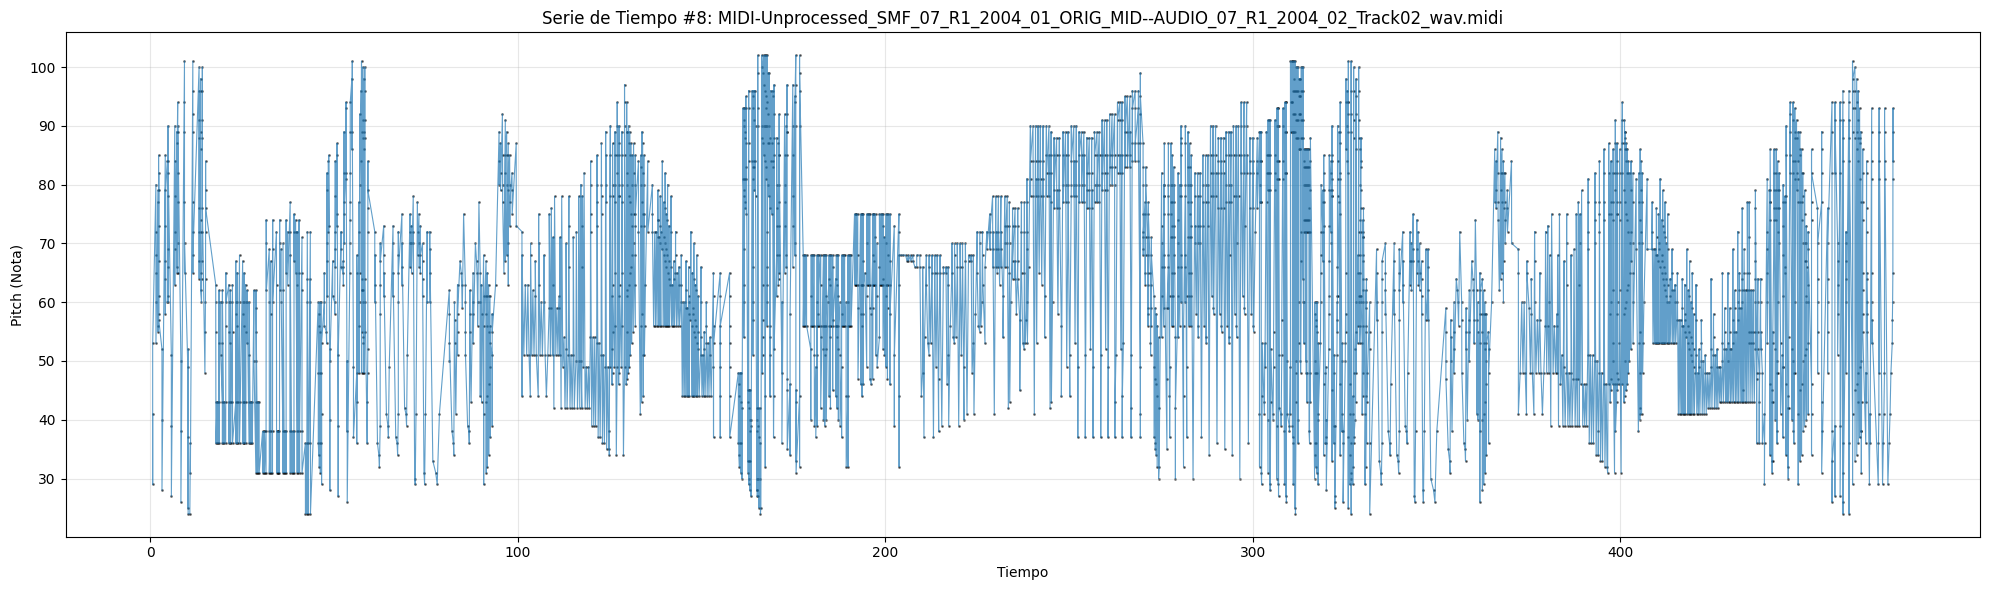

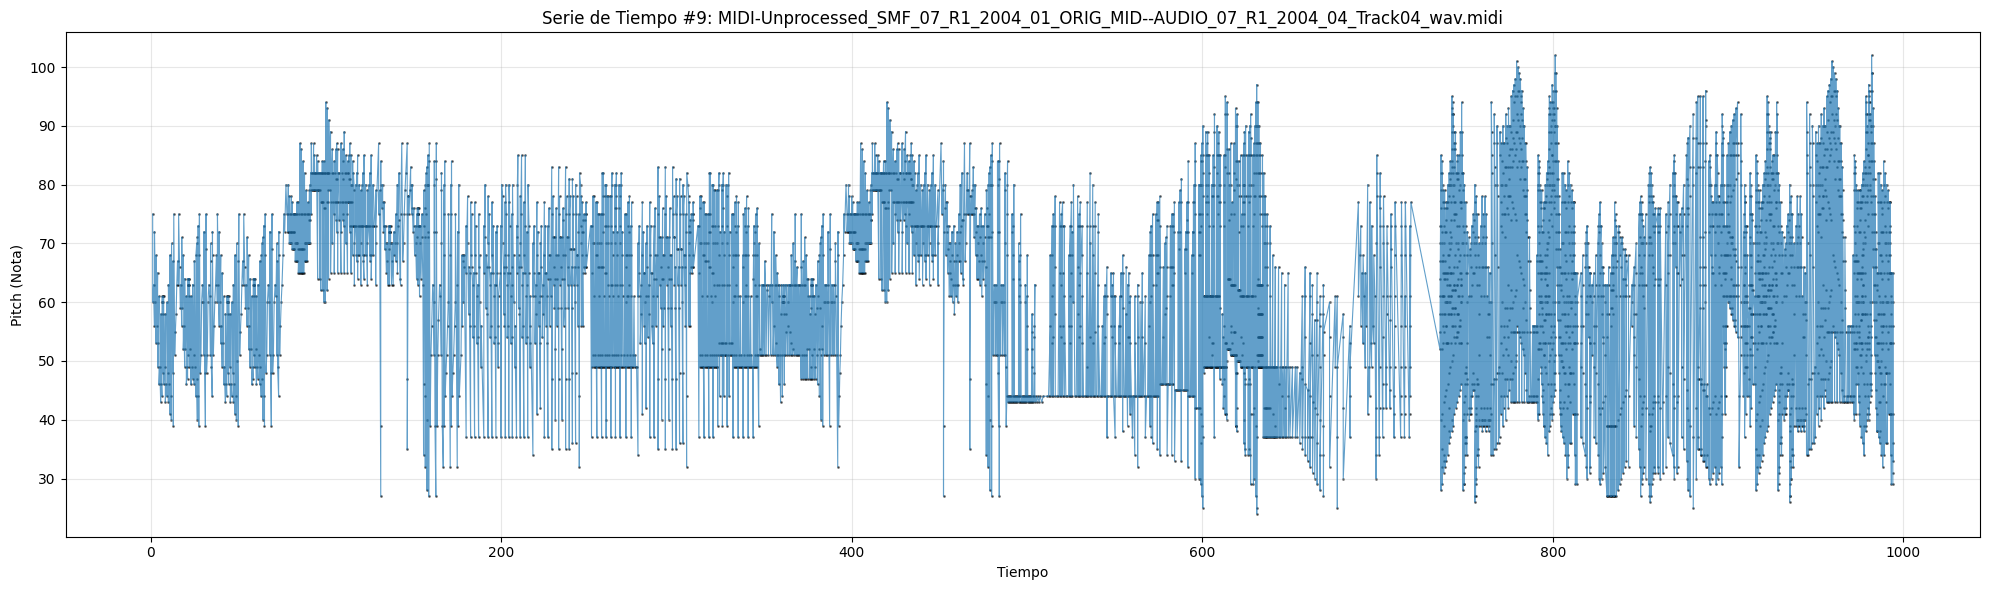

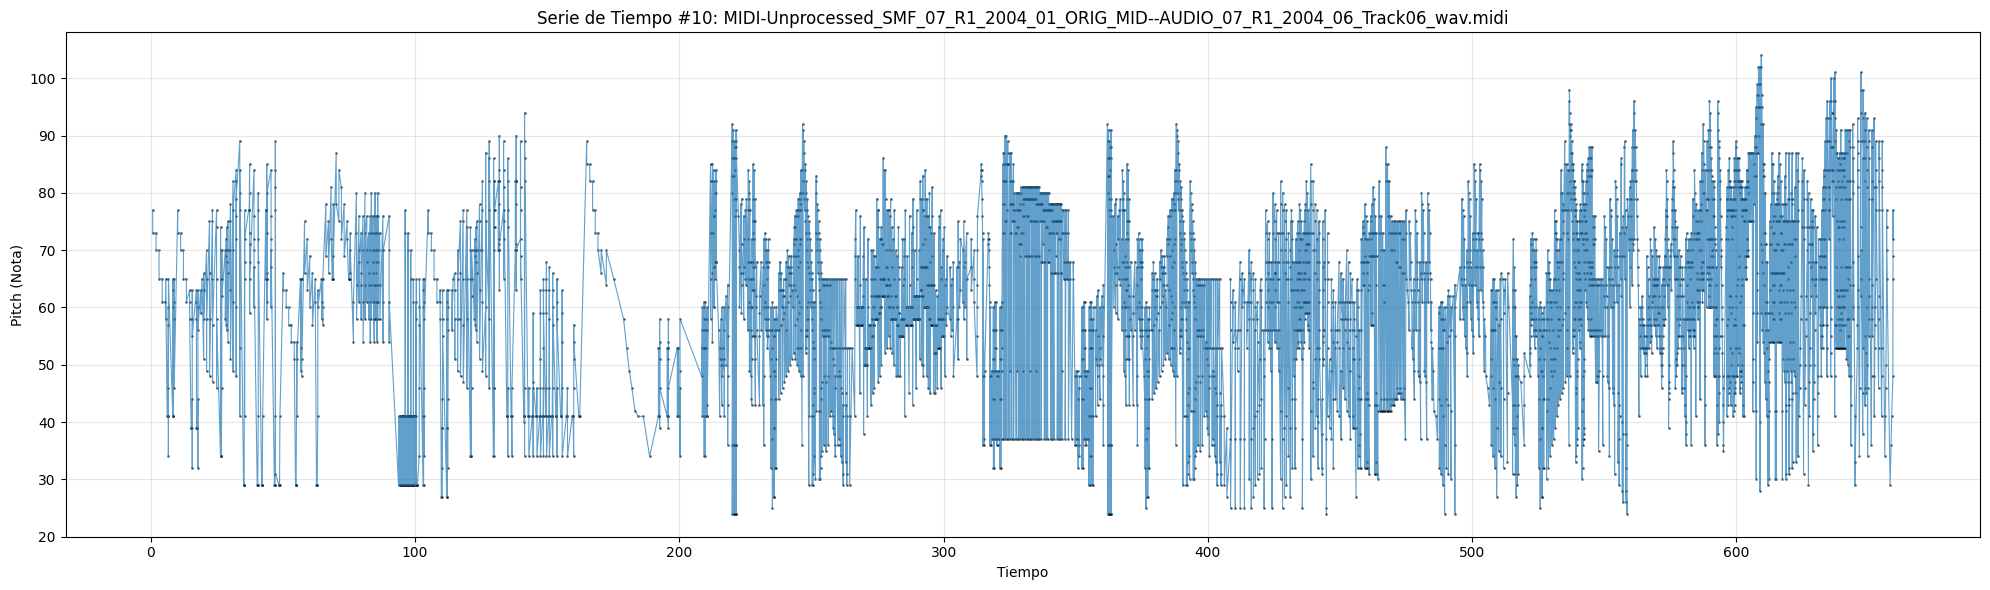

In [6]:
visualizar_por_archivo(archivos, 10)